In [1]:
import pandas as pd
import numpy as np   #numpy는 그냥 부른거
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
rng = np.random.default_rng(42)

n=150 #데이터 150개 뽑겠단 의미

advertising = rng.normal(50,12,n)
visitors = 400 + 8 * advertising + rng.normal(0,80,n)

conversion_rate=rng.normal(0.12,0.02,n)    #값을 흩뿌려넣는 거임, 예쁜 데이터를 뽑을 수 있다.
buyers = visitors * conversion_rate + rng.normal(0,5,n)

sales=20+0.7 * advertising + 0.35 * buyers + rng.normal(0,8,n)
satisfaction = 3.0 + 0.006 * sales + rng.normal(0,0.35,n)

channel = rng.choice(
    ['Online','Offline'],
    size=n    #무작위로 n개의 데이터를 생성한다
)

customer_df=pd.DataFrame({
    'advertising':advertising.round(1),
    'visitors':visitors.round(0).astype(int),
    'buyers':buyers.round(0).astype(int),
    'sales':sales.round(1),
    'satisfaction':np.clip(
        satisfaction,   #고객만족도를 1점부터 5점까지로 추리겠다
        1,
        5,
    ).round(2),
    'channel':channel,
})

customer_df.head()

,advertising,visitors,buyers,sales,satisfaction,channel
0,53.7,817,126,105.6,3.64,Offline
1,37.5,617,57,61.6,3.26,Online
2,59.0,738,111,110.4,3.31,Online
3,61.3,851,107,95.3,4.29,Offline
4,26.6,608,73,58.9,3.98,Online


In [3]:
matrix = pd.DataFrame([
    [10,20,30,40],
    [15,25,35,45],
    [20,30,40,50],
    [25,35,45,55],
],
    index=['A','B','C','D'],
    columns=['W','X','Y','Z']    #2차원 행렬 영어로 matrix , 3차원 vactor
)

matrix

,W,X,Y,Z
A,10,20,30,40
B,15,25,35,45
C,20,30,40,50
D,25,35,45,55


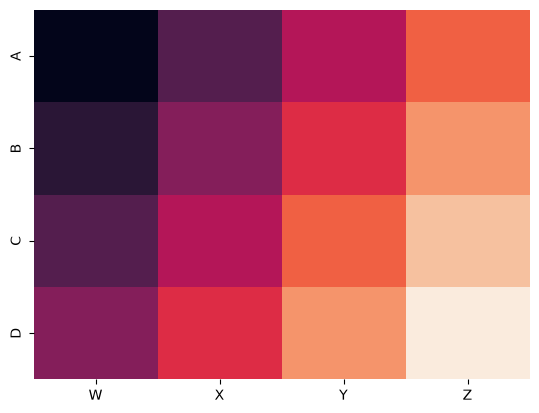

In [4]:
sns.heatmap(
    data=matrix,
    cbar=False)

plt.show()    #낮으면# 낮을수록 진한, 높으면 높을수록 연한 색

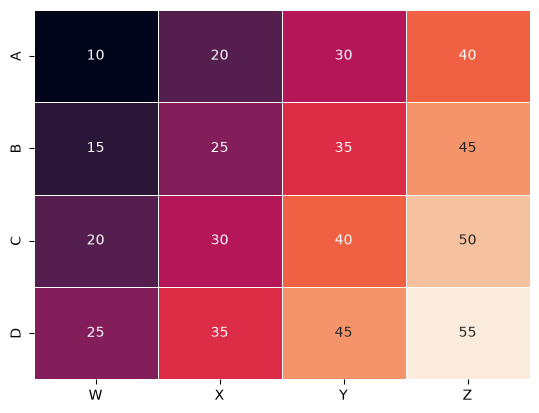

In [5]:
sns.heatmap(
    data=matrix,
    cbar=False,
    annot=True,
    linewidths=0.5    #히트맵에 선을 줄 수 있다
)

plt.show()

In [6]:
print(matrix.to_numpy().min())
print(matrix.to_numpy().max())

10
55


<Axes: >

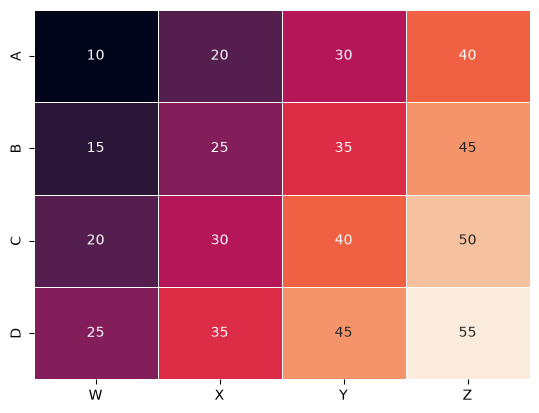

In [7]:
sns.heatmap(
    data=matrix,
    cbar=False,
    annot=True,
    linewidths=0.5
)

상관계수
상관관계는 두개 이상의 변수가 함께 변하는 직선적 경향성의 방향과 세기를 의미한다.

한 변수가 증가하거나 감소할때 다른 변수가 어던 패턴으로 반응하는지를 수치와 방향으로 나타낸 것이다.

상관관계의 종류(방향성)
변수간 변화의 방향에 따라 구분

양의 상관관계(+)
한 변수가 증가할 때, 다른 변수도 같이 증가하는 관계

키가 커질수록 몸무게가 늘어나는 경향, 학습시간이 늘어나면 시험점수가 늘어나는 경향

음의 상관관계(-)
한 변수가 증가할때 다른 변수는 감소하는 관계

자동차의 연비가 높을수록 주유비용이 줄어드는 경향, 기온이 올라갈수록 난방비가 내려가는 경향

상관관계 없음(0)
한 변수의 변화가 다른 변수의 변화에 아무런 영향을 주지 않는 관계

신발 사이즈와 IQ, 통화시간과 시력

수치화
상관관계의 크기와 방향을 숫자로 표준화한 지표, 일반적으로 피어슨 상관계수를 사용
- 상관계수(r)가 1 : 완벽한 양의 상관관계(모든 점이 오른쪽 위로 향하는 직선 위에 있음)
- 0.7<r<1.0 : 강한 양의 상관관계
- 0.3<r<0.7 : 뚜렷한 양의 상관관계
- 0.0<r<0.3 : 약한 양의 상관관계
- 0 : 선형 상관관계 없음(상관관계 없음)
- -0.3<r<0.0 : 약한 음의 상관관계
- -0.7<r<-0.3 : 뚜렷한 음의 상관관계
- -1.0<r<-0.7 : 강한 음의 상관관계
- -1.0 : 완벽한 음의 상관관계

## 주의사항
- 상관관계가 곧 인과관계다라는 오류를 범하면 안된다
  - 두 변수가 함께 움직인다고 해서 한 변수가 다른 변수의 원인은 아니다.
  - 여름철 아이스크림 판매량 , 물놀이 익사사고수는 강한 상관관계를 나타낸다. 두 변수 모두 기온상승이라는 제 3의 변수(교란변수)에 영향을 받았기 때문
- 선형적 관계(직선관계)만 측정
  - 피어슨 상관관계는 직선(Linear) 패턴일때만 정확도가 높다. 두 변수 간의 관계가 U자 모양(비선형) 깊은 연관관계가 있더라도 상관계수가 0에 가깝게 나올 수도 있기 때문
- 이상치에 취약
  - 데이터에 극단적인 값이 단 몇개만이라도 포함되어있을 경우 상관계수 값이 크게 흔들린다.


## 상관계수 행렬
여러 수치형 변수를 분석할 때, 변수 두개씩의 관계를 모두 산점도로 확인할 수 있다.

그러나, 변수가 많아질수록 확인해야 할 조합수가 많이 늘어난다. 따라서 이러한 관계를 숫자로 요약할 때 상관계수를 사용할 수 있다.

In [10]:
numeric_df= customer_df[
    [
        'advertising',
        'visitors',
        'buyers',
        'sales',
        'satisfaction',
    ]
]

numeric_df.head()   #수치형만 뽑아낸거다 numeric

,advertising,visitors,buyers,sales,satisfaction
0,53.7,817,126,105.6,3.64
1,37.5,617,57,61.6,3.26
2,59.0,738,111,110.4,3.31
3,61.3,851,107,95.3,4.29
4,26.6,608,73,58.9,3.98


In [12]:
corr_matrix = numeric_df.corr()   #상관계수 영어로 correlation > 실행하면 행렬 하나 만들어줌,어떤 상관을 가지는지 대각선은 1값을 가짐 나랑 나의 관계니까 , 행렬은 대칭을 가진다.

corr_matrix

,advertising,visitors,buyers,sales,satisfaction
advertising,1.000000,0.736141,0.505584,0.718538,-0.056777
visitors,0.736141,1.000000,0.597025,0.625369,-0.064140
buyers,0.505584,0.597025,1.000000,0.718773,0.063292
sales,0.718538,0.625369,0.718773,1.000000,0.088442
satisfaction,-0.056777,-0.064140,0.063292,0.088442,1.000000


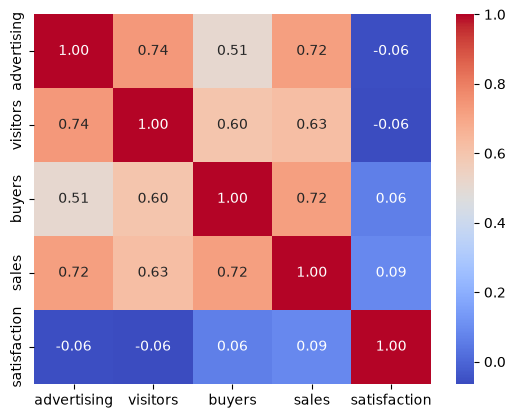

In [16]:
sns.heatmap(
    data=corr_matrix,
    annot=True,
    fmt = '.2f',
    cmap='coolwarm'
)
         #.2f > 소수점 2자리까지 표시해라(나머지는 반올림함)

plt.show()

In [17]:
corr_matrix.loc['advertising','visitors']

np.float64(0.7361407601389484)

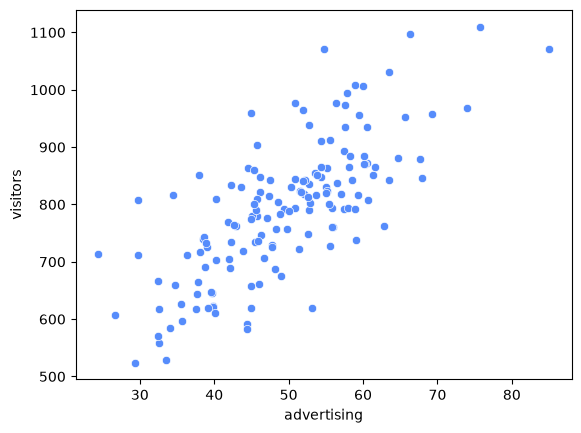

In [18]:
sns.scatterplot(
    data=customer_df,
    x='advertising',
    y='visitors',
)

plt.show()   #데이터가 모여있는 걸 확인할 수 있다,뭔가 증가하는 관계를 갖구나

In [22]:
mask=np.triu(
    np.ones_like(     # 한 번이라도 이 배열에서 값이 출연한 적 있어? 있으면 참 없으면 거짓 출력 이미 참이라고 나왔으면 거짓됨
        corr_matrix,
        dtype=bool
    )
)

mask    #변수 설정(만들고)나서 한 번 더 입력하고 실행해줘야함 (not defined 오류남)

array([[ True,  True,  True,  True,  True],
       [False,  True,  True,  True,  True],
       [False, False,  True,  True,  True],
       [False, False, False,  True,  True],
       [False, False, False, False,  True]])

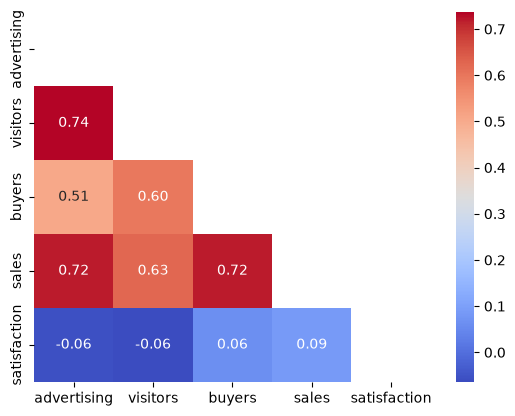

In [23]:
sns.heatmap(
    data=corr_matrix,
    mask=mask,
    cmap='coolwarm',
    annot=True,
    fmt='.2f',
)

plt.show()

In [ ]:
# pairplot = 짝 지어진 상태로 그래프를 만들어주겠다는 의미
# 여러 수치형 변수의 모든 조합을 행렬 형태로 표현

In [25]:
pair_df=customer_df[
    [
        'advertising',
        'visitors',
        'buyers',
        'sales',
    ]
]

pair_df # 4개 변수들의 관계에 대한 그래프16개(4*4)를 pairplot으로 볼 수 있다

,advertising,visitors,buyers,sales
0,53.7,817,126,105.6
1,37.5,617,57,61.6
2,59.0,738,111,110.4
3,61.3,851,107,95.3
4,26.6,608,73,58.9
...,...,...,...,...
145,45.0,774,68,82.7
146,42.7,765,106,101.2
147,48.3,757,90,89.4
148,62.8,762,110,99.3


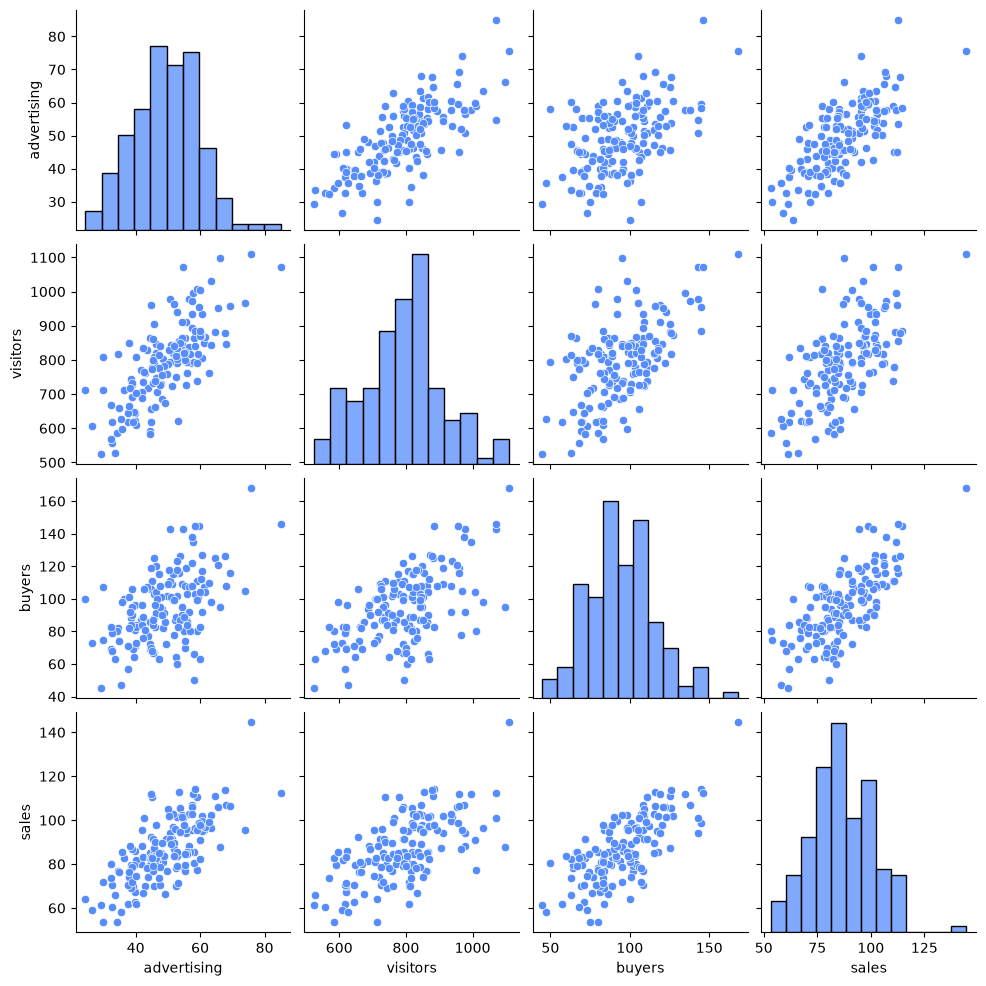

In [26]:
sns.pairplot(
    data=pair_df,
)    #나랑 나 관계에서는 분포를 보여준다.이런 값을 갖구나

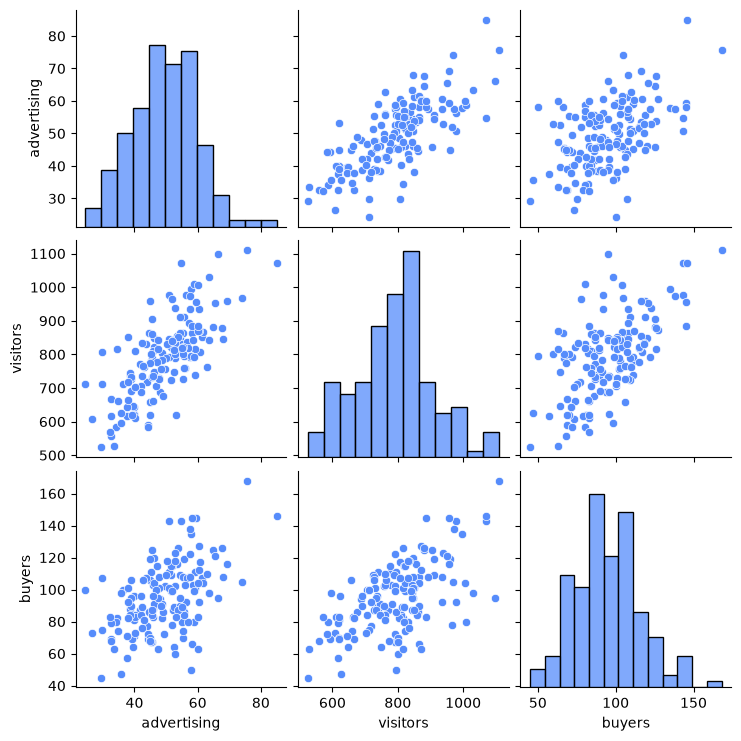

In [27]:
# 변수(variable)> vars로 변수를 담음

sns.pairplot(
    data=pair_df,
    vars=[
        'advertising',
        'visitors',
        'buyers',
    ]
)

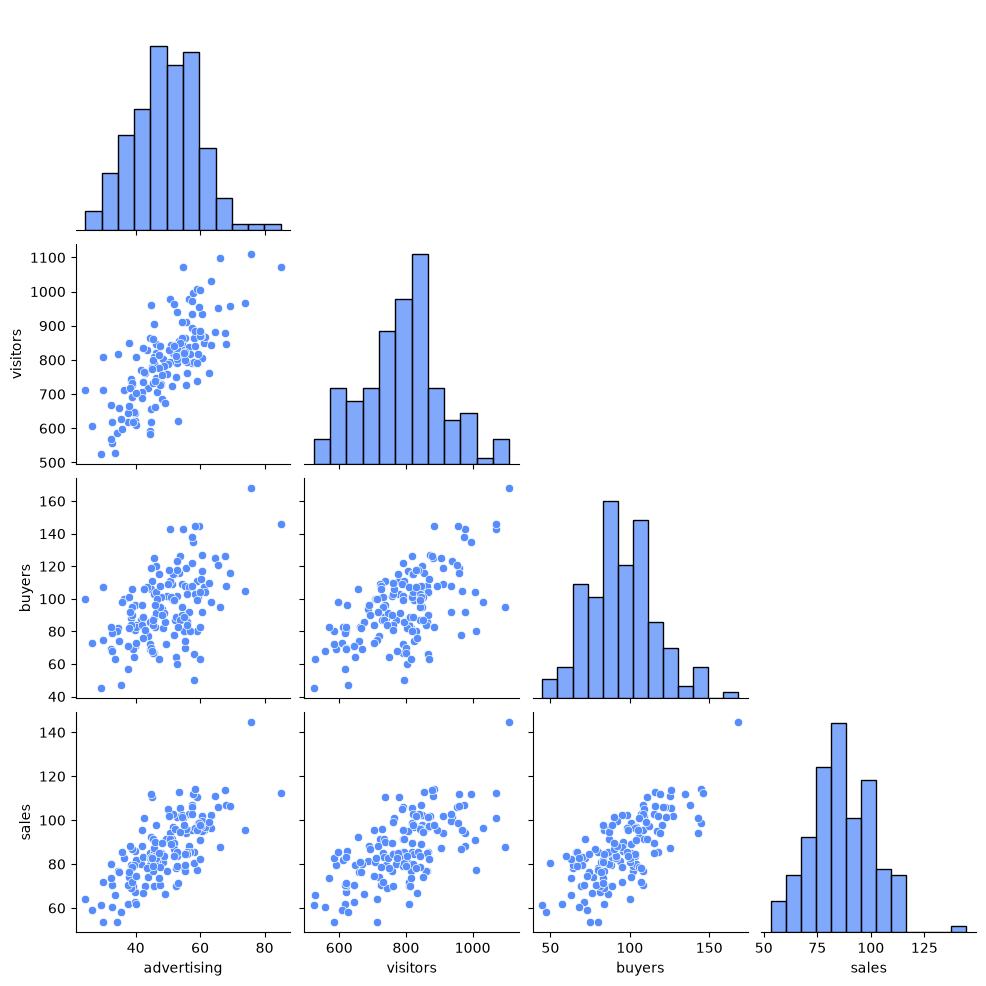

In [28]:
sns.pairplot(
    data=pair_df,
    corner=True,  #중복값 없이 보여주기 위함
)

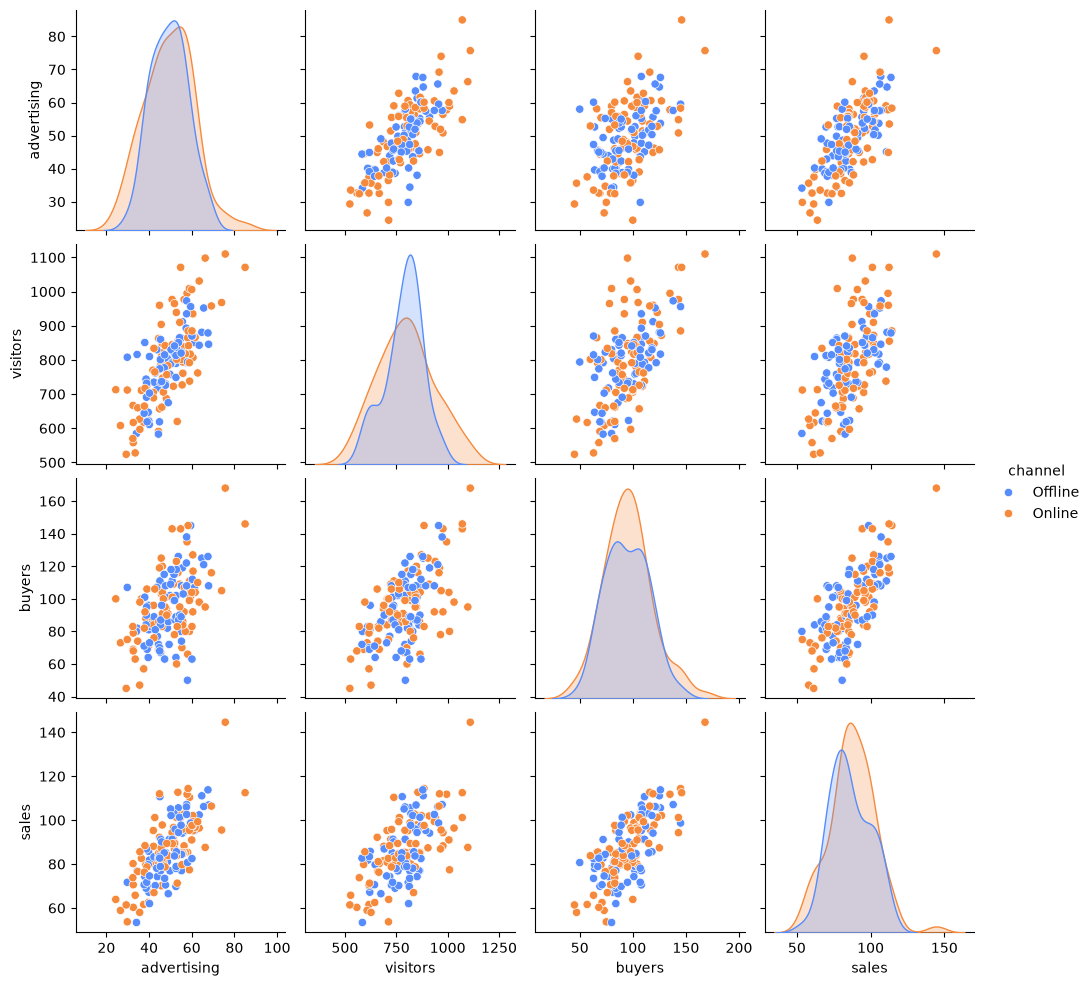

In [30]:
sns.pairplot(
    data=customer_df,
    vars=[
        'advertising',
        'visitors',
        'buyers',
        'sales',
    ],
    hue='channel'
)    #각각 두부별로 컨테이너가 어디에 모이는지 경향을 볼 수 있다. 어느 나라에서 많이 오는지,어느 나라로 많이 가는지 등등